In [16]:
#Loading Dataset
import pandas as pd
import numpy as np

train = pd.read_csv("train.csv")
test = pd.read_csv("test.csv")
features = pd.read_csv("features.csv")
stores = pd.read_csv("stores.csv")

train["Date"] = pd.to_datetime(train["Date"])
test["Date"] = pd.to_datetime(test["Date"])
features["Date"] = pd.to_datetime(features["Date"])

In [17]:
#Merging
train = train.merge(features, on=["Store","Date","IsHoliday"], how="left")
train = train.merge(stores, on="Store", how="left")

test = test.merge(features, on=["Store","Date","IsHoliday"], how="left")
test = test.merge(stores, on="Store", how="left")

In [18]:
#Time Features
for df in [train, test]:
    df["week"] = df["Date"].dt.isocalendar().week.astype(int)
    df["month"] = df["Date"].dt.month
    df["year"] = df["Date"].dt.year

In [19]:
#Lag Features
train = train.sort_values(["Store","Dept","Date"])

for lag in [1,2,3,4]:
    train[f"lag_{lag}"] = train.groupby(["Store","Dept"])["Weekly_Sales"].shift(lag)

train = train.dropna()

In [20]:
#Seleting Features
y = train["Weekly_Sales"]

X = train.drop(["Weekly_Sales","Date"], axis=1)

X = pd.get_dummies(X, columns=["Type"], drop_first=True)
test = pd.get_dummies(test, columns=["Type"], drop_first=True)

test = test.reindex(columns=X.columns, fill_value=0)

In [21]:
#Time-based Split
cutoff = pd.Timestamp("2012-01-01")

train_idx = train["Date"] < cutoff
test_idx = train["Date"] >= cutoff

X_train = X.loc[train_idx]
X_test = X.loc[test_idx]

y_train = y.loc[train_idx]
y_test = y.loc[test_idx]

print(X_train.shape, X_test.shape)

(18698, 22) (78207, 22)


In [22]:
#Regression Model
from sklearn.linear_model import LinearRegression

lr = LinearRegression()
lr.fit(X_train, y_train)
lr_pred = lr.predict(X_test)

In [23]:
#Time-aware Validation
from xgboost import XGBRegressor

xgb = XGBRegressor(
    n_estimators=300,
    max_depth=6,
    learning_rate=0.05,
    objective="reg:squarederror"
)

xgb.fit(X_train, y_train)
xgb_pred = xgb.predict(X_test)

In [24]:
#Evaluation
from sklearn.metrics import mean_absolute_error

print("Linear Regression MAE:", mean_absolute_error(y_test, lr_pred))
print("XGBoost MAE:", mean_absolute_error(y_test, xgb_pred))

Linear Regression MAE: 13694.806898896046
XGBoost MAE: 3008.6459974086674


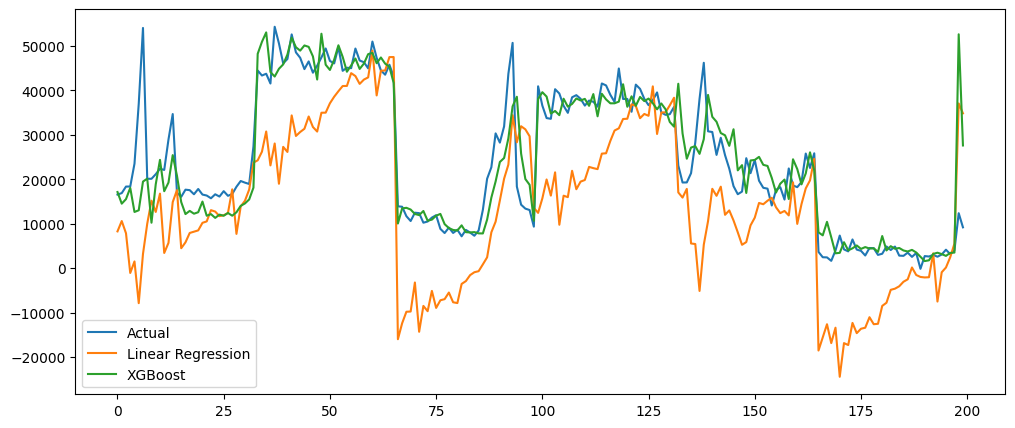

In [25]:
#Visualization
import matplotlib.pyplot as plt

plt.figure(figsize=(12,5))
plt.plot(y_test.values[:200], label="Actual")
plt.plot(lr_pred[:200], label="Linear Regression")
plt.plot(xgb_pred[:200], label="XGBoost")
plt.legend()
plt.show()

In [27]:
#Rolling Average
train["rolling_4"] = (
    train.groupby(["Store","Dept"])["Weekly_Sales"]
         .transform(lambda x: x.rolling(4).mean())
)

train["rolling_8"] = (
    train.groupby(["Store","Dept"])["Weekly_Sales"]
         .transform(lambda x: x.rolling(8).mean())
)

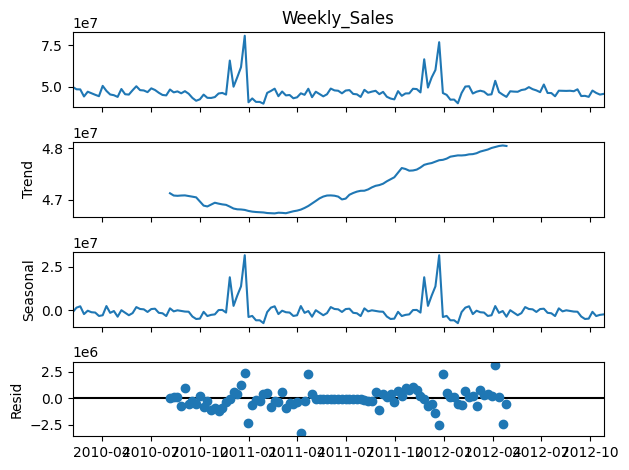

In [29]:
#Seasonal Decomposition
full_sales = (
    pd.read_csv("/content/train.csv")
    .assign(Date=lambda x: pd.to_datetime(x["Date"]))
    .groupby("Date")["Weekly_Sales"]
    .sum()
    .sort_index()
)
from statsmodels.tsa.seasonal import seasonal_decompose
import matplotlib.pyplot as plt

decomp = seasonal_decompose(full_sales, period=52)
decomp.plot()
plt.show()